# Covariance and Correlation

After looking at how a single variable is spread out (variance, standard deviation), the natural next question is: how do two variables move together? That's what covariance and correlation help us answer.

We'll use the tips dataset again, looking at `total_bill` and `tip`, since it's natural to expect these two to move together.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset("tips")
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## What is Covariance?

Covariance tells us whether two variables move together, and in which direction.

* If covariance is **positive**, the variables tend to increase together. When one goes up, the other tends to go up too.
* If covariance is **negative**, they move in opposite directions. When one goes up, the other tends to go down.
* If covariance is **close to zero**, there's no clear linear relationship between them.

For `total_bill` and `tip`, we'd expect a positive covariance, bigger bills usually mean bigger tips.

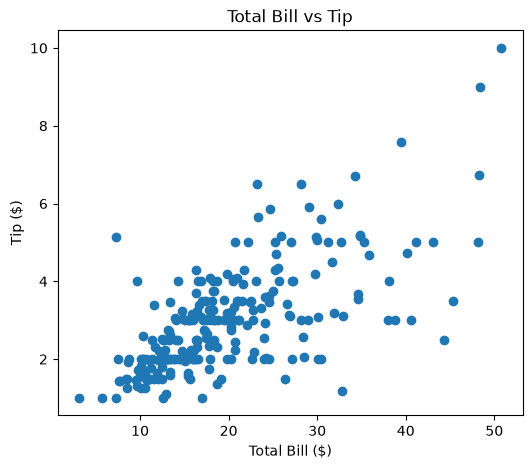

In [2]:
plt.figure(figsize=(6, 5))
plt.scatter(df['total_bill'], df['tip'])
plt.title('Total Bill vs Tip')
plt.xlabel('Total Bill ($)')
plt.ylabel('Tip ($)')
plt.show()

## Covariance Formula

Since we're working with the full dataset of bills we have (not a smaller sample meant to represent a bigger population), we'll treat this as a sample and use the sample covariance formula:

$$s_{xy} = \frac{\sum (X - \bar{x})(Y - \bar{y})}{n - 1}$$

where:
* **X, Y** = the values of total_bill and tip
* **$\bar{x}, \bar{y}$** = the means of total_bill and tip
* **n** = total number of observations

In plain words: for each row, we check how far total_bill is from its average, and how far tip is from its average, multiply those two differences, then average all of that across the dataset.

In [5]:
x_mean = df['total_bill'].mean()
y_mean = df['tip'].mean()
n = df.shape[0]

cov_manual = ((df['total_bill'] - x_mean) * (df['tip'] - y_mean)).sum() / (n - 1)
print(f"Manual sample covariance: {cov_manual:.2f}")

# verify with pandas built-in
cov_builtin = df[['total_bill', 'tip']].cov().loc['total_bill', 'tip']
print(f"Pandas built-in covariance: {cov_builtin:.2f}")

Manual sample covariance: 8.32
Pandas built-in covariance: 8.32


## The Problem With Covariance: Scale Sensitivity

Covariance has one big limitation: it does not tell us the strength of a relationship, because the number is affected by the scale (units) of the variables.

For example, if we scaled up both `total_bill` and `tip` by the same factor, say multiplying each by 3, the covariance would get much larger too, even though the actual relationship between bill and tip hasn't changed at all. The scatter plot would look exactly the same shape, just with bigger numbers on the axes. A bigger covariance number doesn't necessarily mean a stronger relationship, it might just mean the units are bigger.

Let's prove this by scaling both variables up and recalculating covariance.

In [9]:
df_scaled = df.copy()
scale_factor = 3

df_scaled['total_bill_scaled'] = df_scaled['total_bill'] * scale_factor
df_scaled['tip_scaled'] = df_scaled['tip'] * scale_factor

cov_original = df[['total_bill', 'tip']].cov().loc['total_bill', 'tip']
cov_scaled = df_scaled[['total_bill_scaled', 'tip_scaled']].cov().loc['total_bill_scaled', 'tip_scaled']

print(f"Covariance (original scale): {cov_original:.2f}")
print(f"Covariance (scaled x3): {cov_scaled:.2f}")

Covariance (original scale): 8.32
Covariance (scaled x3): 74.91


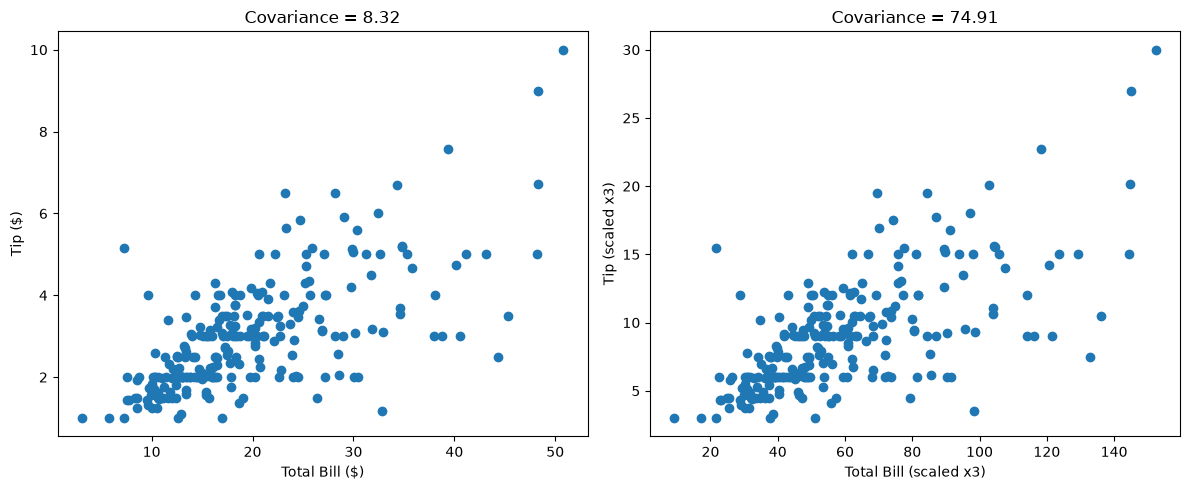

In [8]:
scale_factor = 3

df_scaled['tip_scaled'] = df['tip'] * scale_factor
df_scaled['total_bill_scaled'] = df['total_bill'] * scale_factor

cov_original = df[['total_bill', 'tip']].cov().loc['total_bill', 'tip']
cov_scaled = df_scaled[['total_bill_scaled', 'tip_scaled']].cov().loc['total_bill_scaled', 'tip_scaled']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(df['total_bill'], df['tip'])
axes[0].set_title(f"Covariance = {cov_original:.2f}")
axes[0].set_xlabel('Total Bill ($)')
axes[0].set_ylabel('Tip ($)')

axes[1].scatter(df_scaled['total_bill_scaled'], df_scaled['tip_scaled'])
axes[1].set_title(f"Covariance = {cov_scaled:.2f}")
axes[1].set_xlabel('Total Bill (scaled x3)')
axes[1].set_ylabel('Tip (scaled x3)')

plt.tight_layout()
plt.show()

Both scatter plots show the exact same relationship between total_bill and tip, the shape of the point cloud is identical. The only difference is the scale on both axes, dollars on the left, scaled by 3 on the right.

Yet covariance jumped from 8.32 to 74.91. That's roughly 9 times larger, which makes sense, since we scaled both total_bill and tip by 3, and covariance scales by the product of both factors ($3 \times 3 = 9$).

This confirms the problem clearly. The strength of the relationship between bill and tip hasn't changed one bit, the points follow the exact same pattern in both plots. But the covariance number completely changes depending on the units we use. This is exactly why we can't use covariance alone to compare how strongly different pairs of variables are related, we need a version of this idea that stays the same regardless of scale. That's what correlation does.